In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('~/styles/clarke-default.mplstyle')
import trimesh

### Load the mesh and extract some parameters

In [38]:
# load the stl file defining the extraction region
# mesh = trimesh.load_mesh('/home/clarke/stl/ExtractionRegion.stl')
mesh = trimesh.load_mesh('/home/clarke/stl/infinite_tpc/lxe.stl')
vertices = mesh.vertices

# offset to bring extraction region to its actual size
z_offset = 0 # 6.493

# find the coordinates and radius
min_z = np.min(vertices[:, 2])
max_z = np.max(vertices[:, 2])
bottom_points = vertices[np.isclose(vertices[:, 2], min_z)]
top_points = vertices[np.isclose(vertices[:, 2], max_z)]
bottom_center = np.mean(bottom_points, axis=0)
top_center = np.mean(top_points, axis=0)
# radius = np.mean(np.linalg.norm(bottom_points[:,:2] - bottom_center[:2], axis=1))
radius = 400. # set the radius in which events will be created manually
height = max_z - min_z

### Generate some points along the liquid surface

In [45]:
n_points = 100_000
points_rt = np.random.uniform([0., 0.], [radius**2, 2.*np.pi], size=(n_points, 2))
points_rt[:, 0] = np.sqrt(points_rt[:, 0])
points_rtz = np.hstack([points_rt, (max_z + z_offset)*np.ones(n_points)[:, np.newaxis]])

points_xyz = np.zeros_like(points_rtz)
points_xyz[:, 0] = points_rtz[:, 0] * np.cos(points_rtz[:, 1])
points_xyz[:, 1] = points_rtz[:, 0] * np.sin(points_rtz[:, 1])
points_xyz[:, 2] = points_rtz[:, 2]

Text(0.5, 0.98, 'Points sampled in extraction region')

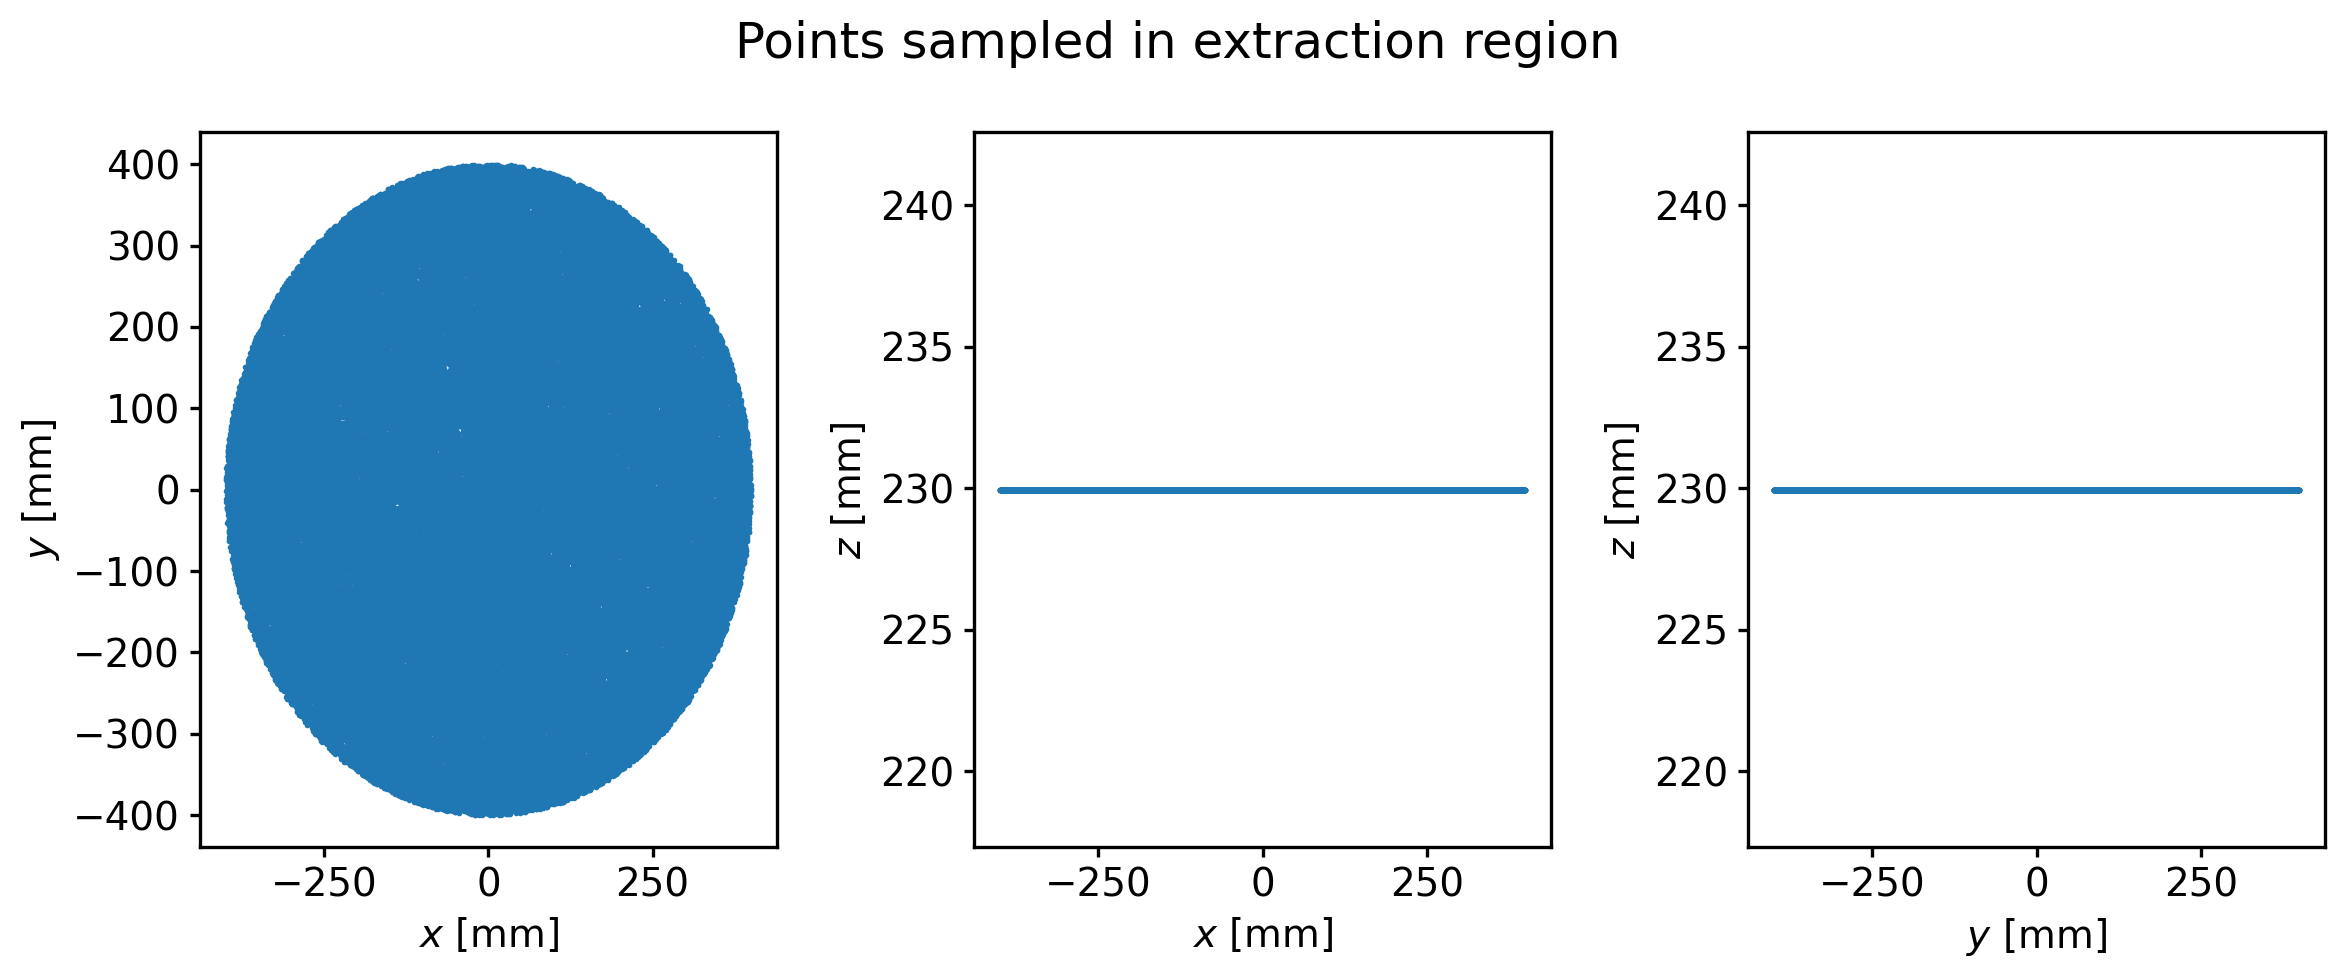

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax1, ax2, ax3 = ax

ax1.scatter(points_xyz[:, 0], points_xyz[:, 1], s=1)
ax1.set_xlabel('$x$ [mm]')
ax1.set_ylabel('$y$ [mm]')

ax2.scatter(points_xyz[:, 0], points_xyz[:, 2], s=1)
ax2.set_xlabel('$x$ [mm]')
ax2.set_ylabel('$z$ [mm]')

ax3.scatter(points_xyz[:, 1], points_xyz[:, 2], s=1)
ax3.set_xlabel('$y$ [mm]')
ax3.set_ylabel('$z$ [mm]')

fig.suptitle('Points sampled in extraction region')

### Save the points to a file
Make sure to rerun the random point generation between running the next two cells!

In [44]:
np.save('chroma-lxe/data/infinite_tpc/lxe_surface_{:.0f}mm_rad_site1.npy'.format(radius), points_xyz, allow_pickle=False)

In [47]:
np.save('chroma-lxe/data/infinite_tpc/lxe_surface_{:.0f}mm_rad_site2.npy'.format(radius), points_xyz, allow_pickle=False)

### Check the $z$-position of the PMTs

In [23]:
mesh = trimesh.load_mesh('/home/clarke/stl/PMT1_shifted.stl')
vertices = mesh.vertices

# offset to bring extraction region to its actual size
z_offset = 6.493

# find the coordinates and radius
min_z = np.min(vertices[:, 2])

### Verify that the two positions are different

In [21]:
site1 = np.load('chroma-lxe/data/XeNu_LXe_surface_points.npy')
site2 = np.load('chroma-lxe/data/XeNu_LXe_surface_points_site2.npy')
print(site1[:5,:])
print(site2[:5,:])

[[   5.97218775   -2.63318069 -379.26258472]
 [ -12.74641413   -9.05029424 -379.26258472]
 [  18.16618787   -3.42306008 -379.26258472]
 [  -4.00565349  -18.59861012 -379.26258472]
 [  -3.45958333   12.34682531 -379.26258472]]
[[-6.70823277e+00  1.03218800e+01 -3.79262585e+02]
 [ 1.31278162e+01 -2.60341714e-01 -3.79262585e+02]
 [-7.61528321e+00  1.64135455e+01 -3.79262585e+02]
 [-9.58230719e+00  1.07728350e+01 -3.79262585e+02]
 [-6.46507636e+00  1.78359016e+01 -3.79262585e+02]]


In [5]:
points_xyz

array([[   9.20050932,   13.21406565, -379.26258472],
       [  -9.62632624,    7.72545098, -379.26258472],
       [ -13.90253441,   -2.12189016, -379.26258472],
       ...,
       [   1.38706209,  -10.86731162, -379.26258472],
       [   2.691292  ,  -17.63894363, -379.26258472],
       [ -13.06293804,    2.46718013, -379.26258472]])

In [4]:
mesh = trimesh.load_mesh('/home/clarke/stl/SiPMPixel1.stl')
mesh.vertices

TrackedArray([[  15.74793816,   15.84477425, -362.05828857],
              [  15.74793816,   21.79477501, -362.05828857],
              [  15.74793816,   15.84477425, -362.10830688],
              [  15.74793816,   21.79477501, -362.10830688],
              [  21.59793854,   15.84477425, -362.05828857],
              [  21.59793854,   15.84477425, -362.10830688],
              [  21.59793854,   21.79477501, -362.05828857],
              [  21.59793854,   21.79477501, -362.10830688]])

In [5]:
mesh = trimesh.load_mesh('/home/clarke/stl/SiPMSurface1.stl')
mesh.vertices

TrackedArray([[   9.39793777,   21.79477501, -362.10830688],
              [   9.39793777,   15.84477425, -362.10830688],
              [   9.39793777,   21.79477501, -362.05828857],
              [   9.39793777,   15.84477425, -362.05828857],
              [  15.24793816,   21.79477501, -362.10830688],
              [  15.24793816,   21.79477501, -362.05828857],
              [  15.24793816,   15.84477425, -362.10830688],
              [  15.24793816,   15.84477425, -362.05828857],
              [   9.39793777,   15.34477425, -362.10830688],
              [   9.39793777,    9.39477444, -362.10830688],
              [   9.39793777,   15.34477425, -362.05828857],
              [   9.39793777,    9.39477444, -362.05828857],
              [  15.24793816,   15.34477425, -362.10830688],
              [  15.24793816,   15.34477425, -362.05828857],
              [  15.24793816,    9.39477444, -362.10830688],
              [  15.24793816,    9.39477444, -362.05828857],
              [  15.7479

In [6]:
dir(mesh)

['__abstractmethods__',
 '__add__',
 '__annotations__',
 '__class__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_cache',
 '_data',
 '_visual',
 'apply_obb',
 'apply_scale',
 'apply_transform',
 'apply_translation',
 'area',
 'area_faces',
 'as_open3d',
 'body_count',
 'bounding_box',
 'bounding_box_oriented',
 'bounding_cylinder',
 'bounding_primitive',
 'bounding_sphere',
 'bounds',
 'center_mass',
 'centroid',
 'compute_stable_poses',
 'contains',
 'convert_units',
 'convex_decomposition',
 'convex_hull',
 'copy',
 'density',
 'difference',
 'edges',
 'edges_face',
 'edges_sorted',
 'edges_sorted_tree',


In [37]:
mesh = trimesh.load_mesh('/home/clarke/stl/infinite_tpc/pmt_51mm_91pct_0.stl')
vertices = mesh.vertices
vertices

TrackedArray([[-326.55273438, -101.59999847,  249.80000305],
              [-351.95272827, -101.59999847,  249.80000305],
              [-326.56524658, -100.8021698 ,  249.80000305],
              ...,
              [-326.60284424, -103.19487762,  249.8999939 ],
              [-326.56524658, -102.39783478,  249.80000305],
              [-326.56524658, -102.39783478,  249.8999939 ]])